# Assignment 8 — CNN Image Classification with PyTorch
## FashionMNIST

**Student ID:** `220144`

---

I train a convolutional neural network on the standard FashionMNIST dataset and then use
it to classify ten custom photographs supplied in my `dataset/` folder.

The notebook is designed to be reproducible with **Runtime → Run all**:

1. Clones my GitHub repository when a public repository URL is configured and the project is not already present.
2. Downloads the standard FashionMNIST dataset via `torchvision.datasets`.
3. Builds the CNN using `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.Linear`.
4. Trains it, or loads the saved `220144.pth` state dictionary when available.
5. Evaluates it using training curves, a confusion matrix, classification report, and visual error analysis.
6. Classifies my exact 10 custom images and prints each predicted class with its softmax confidence.
7. Requires no manual image upload during runtime.

### My 10 custom images

| # | Filename |
|---|---|
| 1 | `01_shirt.jpg` |
| 2 | `02_hoodie.jpg` |
| 3 | `03_cardigan.jpg` |
| 4 | `04_jacket.jpg` |
| 5 | `05_dress.jpg` |
| 6 | `06_cap.jpg` |
| 7 | `07_sandal.jpg` |
| 8 | `08_boot.jpg` |
| 9 | `09_backpack.jpg` |
| 10 | `10_Handbag.jpg` |

The original filenames are preserved throughout the notebook. The custom filenames are treated as input-file identifiers; the model's predicted class comes from the model output.


---
## 0. Configuration

I keep every adjustable value in this one cell.


In [1]:
# ---- Identity -------------------------------------------------------------
STUDENT_ID  = "220144"

REPO_URL = "https://github.com/abir945/AI_ML_LAB.git"

# ---- Training hyper-parameters --------------------------------------------
EPOCHS        = 15
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
VAL_FRACTION  = 0.10
SEED          = 42

# False: reuse model/220144.pth when it exists.
# True : train from scratch even when saved weights exist.
FORCE_RETRAIN = False

# ---- Exact custom files supplied by the student ----------------------------
CUSTOM_FILENAMES = [
    "01_shirt.jpg",
    "02_hoodie.jpg",
    "03_cardigan.jpg",
    "04_jacket.jpg",
    "05_dress.jpg",
    "06_cap.jpg",
    "07_sandal.jpg",
    "08_boot.jpg",
    "09_backpack.jpg",
    "10_Handbag.jpg",
]

print(f"Student ID : {STUDENT_ID}")
print(f"Repository : {REPO_URL if REPO_URL else '[set REPO_URL before fresh Colab Run All]'}")
print(f"Custom images: {len(CUSTOM_FILENAMES)}")

Student ID : 220144
Repository : https://github.com/abir945/AI_ML_LAB.git
Custom images: 10


---
## 1. Automatic data retrieval

I pull two independent sources with no manual image upload:

* the **10 custom images** and the **saved model weights** from the project repository when a GitHub URL is configured;
* the **standard FashionMNIST dataset** through `torchvision.datasets`.


In [2]:
import os
import subprocess
import sys
import json
import random
import time
from pathlib import Path

# Clone only when the project files are not already next to the notebook.
project_candidates = [
    Path.cwd(),
    Path("/content/CNN_Image_Classification_220144"),
    Path("/content/CNN"),
    Path("/content/AI_ML_LAB/CNN"),
]

PROJECT_ROOT = None

for candidate in project_candidates:
    if (candidate / "dataset").is_dir():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None and REPO_URL.strip():
    clone_dir = Path("/content/AI_ML_LAB")
    if not clone_dir.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)],
            check=True
        )

    # The dataset is specifically under CNN/dataset in this repo
    if (clone_dir / "CNN" / "dataset").is_dir():
        PROJECT_ROOT = (clone_dir / "CNN").resolve()
    else:
        PROJECT_ROOT = clone_dir.resolve()

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root could not be found. Put the notebook beside the dataset/ folder "
        "or set REPO_URL to your public GitHub repository before running in a fresh Colab."
    )

DATASET_DIR  = PROJECT_ROOT / "dataset"
MODEL_DIR    = PROJECT_ROOT / "model"
ASSET_DIR    = PROJECT_ROOT / "assets"
DATA_DIR     = PROJECT_ROOT / "data"
WEIGHTS_PATH = MODEL_DIR / f"{STUDENT_ID}.pth"
HISTORY_PATH = ASSET_DIR / "history.json"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.is_dir():
    raise FileNotFoundError(f"Custom dataset directory not found: {DATASET_DIR}")

# Validate exact custom file set.
missing = [name for name in CUSTOM_FILENAMES if not (DATASET_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(
        "The following required custom images are missing: " + ", ".join(missing)
    )

extra_images = sorted(
    p.name for p in DATASET_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    and p.name not in CUSTOM_FILENAMES
)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("custom photos:", f"{len(CUSTOM_FILENAMES)} found -> {CUSTOM_FILENAMES}")
print("saved weights:", "found" if WEIGHTS_PATH.exists() else "not found (will train)")
if extra_images:
    print("extra image files (not used):", extra_images)

PROJECT_ROOT : /content/AI_ML_LAB/CNN
custom photos: 10 found -> ['01_shirt.jpg', '02_hoodie.jpg', '03_cardigan.jpg', '04_jacket.jpg', '05_dress.jpg', '06_cap.jpg', '07_sandal.jpg', '08_boot.jpg', '09_backpack.jpg', '10_Handbag.jpg']
saved weights: not found (will train)


In [3]:
import numpy as np
import torch
import torch.nn as nn

from PIL import Image, ImageOps

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
print("torch", torch.__version__)

torch 2.11.0+cpu


---
## 2. Data preprocessing

I use `EVAL_TRANSFORM` as the single source of truth for inference. The same
Resize → ToTensor → Normalize pipeline is applied to the standard test set
and to the custom photographs after the real-world preparation step.

`Grayscale(1)` keeps FashionMNIST single-channel and converts RGB custom photos
to the one-channel format expected by the CNN.


In [8]:
# FashionMNIST class names used by torchvision.
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

IMG_SIZE = 28
NUM_CLASSES = 10

# FashionMNIST training-split channel statistics.
FMNIST_MEAN = (0.2860,)
FMNIST_STD  = (0.3530,)

EVAL_TRANSFORM = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
])

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=8,
        translate=(0.08, 0.08),
        scale=(0.92, 1.08),
    ),
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
])


def denormalize(tensor):
    """Undo Normalize so a tensor can be shown with matplotlib."""
    return (tensor * FMNIST_STD[0] + FMNIST_MEAN[0]).clamp(0, 1)

In [5]:
# FashionMNIST is downloaded automatically by torchvision.
full_train = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=TRAIN_TRANSFORM,
)

# The same 60,000 training files are viewed through the non-random eval transform
# when measuring validation performance.
full_eval = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=EVAL_TRANSFORM,
)

test_set = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=EVAL_TRANSFORM,
)

n_val = int(len(full_train) * VAL_FRACTION)
n_train = len(full_train) - n_val

train_idx, val_idx = random_split(
    range(len(full_train)),
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

train_set = Subset(full_train, list(train_idx))
val_set = Subset(full_eval, list(val_idx))

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Train      : {len(train_set):,} images  ({len(train_loader)} batches)")
print(f"Validation : {len(val_set):,} images  ({len(val_loader)} batches)")
print(f"Test       : {len(test_set):,} images  ({len(test_loader)} batches)")

images, labels = next(iter(train_loader))
print(f"\nOne batch  : {tuple(images.shape)}  (batch, channels, height, width)")
print(f"Value range: [{images.min():.2f}, {images.max():.2f}]  (post-normalisation)")

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 233kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.4MB/s]


Train      : 54,000 images  (844 batches)
Validation : 6,000 images  (94 batches)
Test       : 10,000 images  (157 batches)

One batch  : (64, 1, 28, 28)  (batch, channels, height, width)
Value range: [-0.81, 2.02]  (post-normalisation)


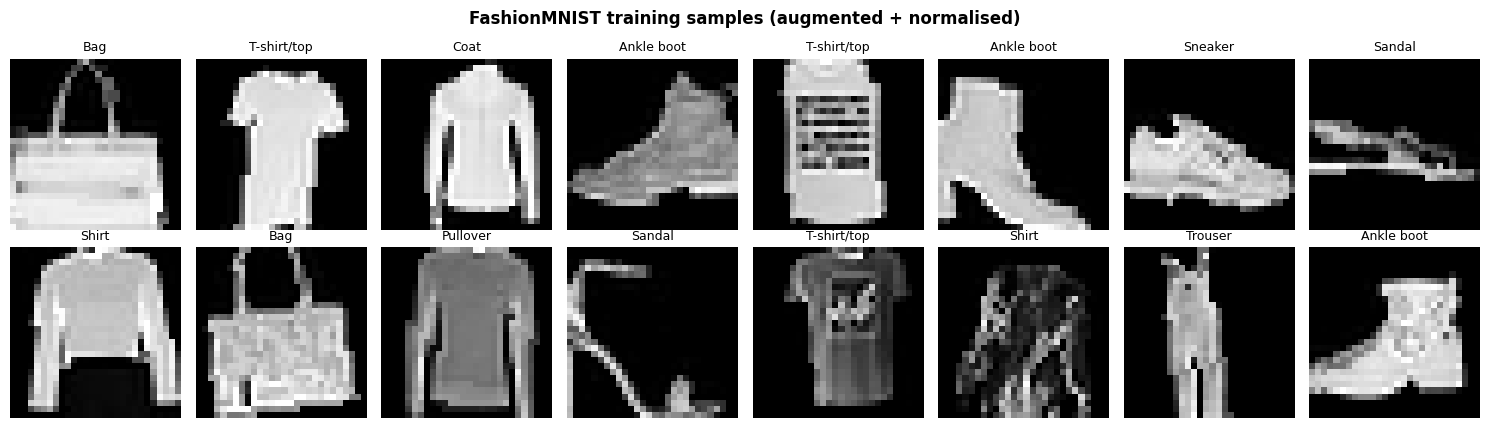

In [9]:
# A quick look at what the network receives after preprocessing.
fig, axes = plt.subplots(2, 8, figsize=(15, 4.4))

for ax, img, lab in zip(axes.ravel(), images, labels):
    ax.imshow(denormalize(img).squeeze(0).numpy(), cmap="gray")
    ax.set_title(CLASS_NAMES[int(lab)], fontsize=9)
    ax.axis("off")

fig.suptitle(
    "FashionMNIST training samples (augmented + normalised)",
    fontweight="bold",
)
fig.tight_layout()
plt.show()


---
## 3. CNN model architecture

I use a three-block VGG-style convolutional network.

| Stage | Operation | Output shape |
|---|---|---|
| input | — | `1 × 28 × 28` |
| block 1 | 2× Conv(3×3, 32) → MaxPool | `32 × 14 × 14` |
| block 2 | 2× Conv(3×3, 64) → MaxPool | `64 × 7 × 7` |
| block 3 | 1× Conv(3×3, 128) → MaxPool | `128 × 3 × 3` |
| head | Flatten → Linear(1152→256) → ReLU → Dropout → Linear(256→10) | `10` |

The network returns raw logits. `nn.CrossEntropyLoss` handles the training loss,
while `torch.softmax` is applied explicitly during custom-image prediction.


In [6]:
class CNN(nn.Module):
    """Three-block VGG-style CNN for 1x28x28 FashionMNIST images."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
model = CNN().to(device)

print(f"Device: {device}\n")

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

print("\nShape flow through the network:")
with torch.no_grad():
    x = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE, device=device)
    print(f"  input          {tuple(x.shape)}")
    for name in ("block1", "block2", "block3"):
        x = getattr(model, name)(x)
        print(f"  after {name}   {tuple(x.shape)}")
    x = model.classifier(x)
    print(f"  logits         {tuple(x.shape)}")

Device: cpu

Total parameters    : 437,226
Trainable parameters: 437,226

Shape flow through the network:
  input          (1, 1, 28, 28)
  after block1   (1, 32, 14, 14)
  after block2   (1, 64, 7, 7)
  after block3   (1, 128, 3, 3)
  logits         (1, 10)


---
## 4. Training loop

* **Loss:** `nn.CrossEntropyLoss`
* **Optimizer:** `torch.optim.Adam` with learning rate `1e-3`
* **Loop:** `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()`
* **Saving:** `torch.save(model.state_dict(), 'model/220144.pth')`

The best validation-accuracy checkpoint is restored before saving.


In [7]:
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, criterion, optimizer, device):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, seen = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)
            if training:
                optimizer.zero_grad()
            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch_labels.size(0)
            correct += (outputs.argmax(1) == batch_labels).sum().item()
            seen += batch_labels.size(0)
    return total_loss / seen, correct / seen

def train_model(model, train_loader, val_loader, device, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.3)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = run_epoch(model, val_loader, criterion, None, device)
        scheduler.step()
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"Epoch {epoch:2d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc*100:5.2f}% | val loss {va_loss:.4f} acc {va_acc*100:5.2f}% | {time.time()-t0:5.1f}s")
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\nRestored best checkpoint (validation accuracy {best_acc*100:.2f}%).")
    return history

have_weights = WEIGHTS_PATH.exists()
if have_weights and not FORCE_RETRAIN:
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
    model.to(device)
    print(f"Loaded saved weights from {WEIGHTS_PATH.relative_to(PROJECT_ROOT)}")
    if HISTORY_PATH.exists():
        with HISTORY_PATH.open(encoding='utf-8') as fh: history = json.load(fh)
    else: history = None
else:
    print(f"Training for {EPOCHS} epochs on {device} ...\n")
    history = train_model(model, train_loader, val_loader, device, EPOCHS, LEARNING_RATE)
    torch.save(model.state_dict(), WEIGHTS_PATH)
    with HISTORY_PATH.open('w', encoding='utf-8') as fh: json.dump(history, fh, indent=2)
    print(f"\nSaved state dict -> {WEIGHTS_PATH.relative_to(PROJECT_ROOT)}")

Training for 15 epochs on cpu ...

Epoch  1/15 | train loss 0.6821 acc 74.43% | val loss 0.4196 acc 84.10% | 285.7s
Epoch  2/15 | train loss 0.4738 acc 82.49% | val loss 0.3419 acc 87.52% | 287.3s
Epoch  3/15 | train loss 0.4208 acc 84.71% | val loss 0.3068 acc 88.88% | 287.9s
Epoch  4/15 | train loss 0.3936 acc 85.75% | val loss 0.2956 acc 88.93% | 284.8s
Epoch  5/15 | train loss 0.3727 acc 86.29% | val loss 0.2805 acc 89.43% | 285.3s
Epoch  6/15 | train loss 0.3580 acc 87.09% | val loss 0.2639 acc 90.12% | 283.2s
Epoch  7/15 | train loss 0.3176 acc 88.66% | val loss 0.2461 acc 90.95% | 284.5s
Epoch  8/15 | train loss 0.3049 acc 88.79% | val loss 0.2396 acc 91.00% | 283.3s
Epoch  9/15 | train loss 0.3003 acc 89.25% | val loss 0.2338 acc 91.57% | 285.2s
Epoch 10/15 | train loss 0.2948 acc 89.38% | val loss 0.2326 acc 91.58% | 283.8s
Epoch 11/15 | train loss 0.2902 acc 89.55% | val loss 0.2373 acc 91.33% | 285.2s
Epoch 12/15 | train loss 0.2890 acc 89.45% | val loss 0.2236 acc 92.05% | 

---
## 5. Evaluation on the standard test set

### 5.1 Training history — Loss vs Epochs and Accuracy vs Epochs


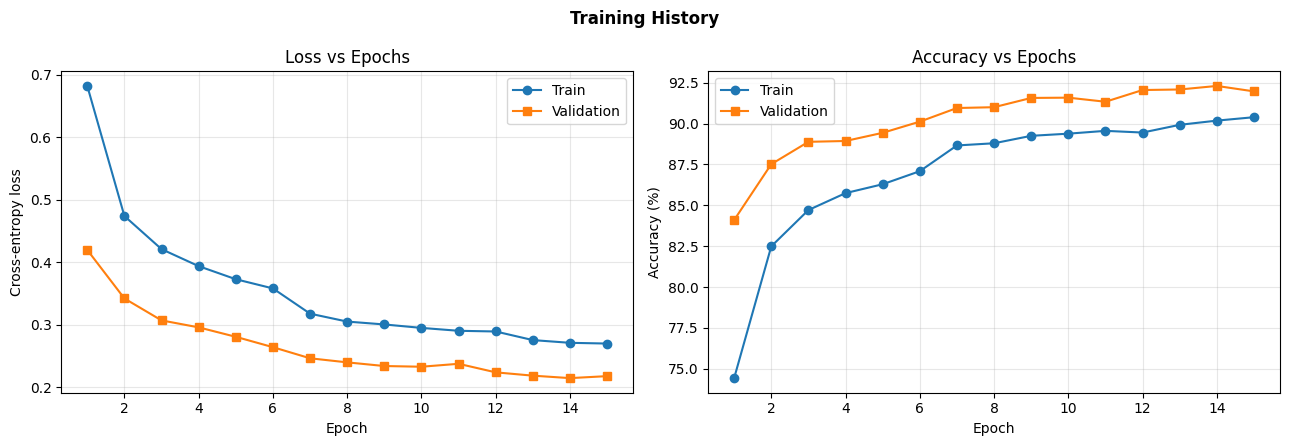

In [10]:
if history is None:
    print("Training history is unavailable.")
else:
    epochs_axis = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(epochs_axis, history["train_loss"], "o-", label="Train")
    axes[0].plot(epochs_axis, history["val_loss"], "s-", label="Validation")
    axes[0].set_title("Loss vs Epochs")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[1].plot(epochs_axis, [a * 100 for a in history["train_acc"]], "o-", label="Train")
    axes[1].plot(epochs_axis, [a * 100 for a in history["val_acc"]], "s-", label="Validation")
    axes[1].set_title("Accuracy vs Epochs")
    axes[1].set_ylabel("Accuracy (%)")
    for ax in axes: ax.set_xlabel("Epoch"); ax.grid(alpha=0.3); ax.legend()
    fig.suptitle("Training History", fontweight="bold")
    fig.tight_layout()
    plt.show()

### 5.2 Overall accuracy and per-class report


In [11]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    preds, targets = [], []
    for batch_images, batch_labels in loader:
        preds.append(model(batch_images.to(device)).argmax(1).cpu())
        targets.append(batch_labels)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

test_preds, test_targets = collect_predictions(model, test_loader, device)
test_acc = (test_preds == test_targets).mean()
print(f"Standard FashionMNIST test-set accuracy: {test_acc*100:.2f}% ({int((test_preds == test_targets).sum()):,} / {len(test_targets):,})\n")
print(classification_report(test_targets, test_preds, target_names=CLASS_NAMES, digits=4))

Standard FashionMNIST test-set accuracy: 91.91% (9,191 / 10,000)

              precision    recall  f1-score   support

 T-shirt/top     0.8560    0.8800    0.8679      1000
     Trouser     0.9900    0.9890    0.9895      1000
    Pullover     0.8789    0.9000    0.8893      1000
       Dress     0.9187    0.9260    0.9223      1000
        Coat     0.8621    0.8880    0.8749      1000
      Sandal     0.9878    0.9740    0.9809      1000
       Shirt     0.7816    0.7120    0.7452      1000
     Sneaker     0.9413    0.9780    0.9593      1000
         Bag     0.9910    0.9890    0.9900      1000
  Ankle boot     0.9775    0.9550    0.9661      1000

    accuracy                         0.9191     10000
   macro avg     0.9185    0.9191    0.9185     10000
weighted avg     0.9185    0.9191    0.9185     10000



### 5.3 Confusion matrix heatmap


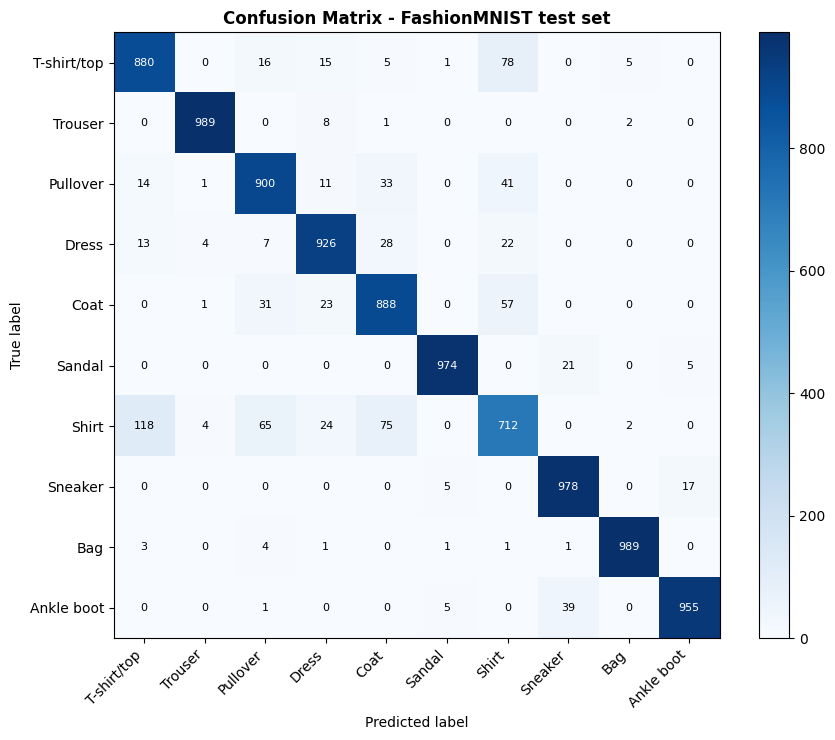

In [12]:
cm = confusion_matrix(test_targets, test_preds, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm, cmap="Blues")
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix - FashionMNIST test set", fontweight="bold")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8, color=("white" if cm[i, j] > cm.max() * 0.55 else "black"))
fig.tight_layout()
plt.show()

### 5.4 Visual error analysis

Three randomly chosen test images the model got **wrong**, with the true label against the predicted label.


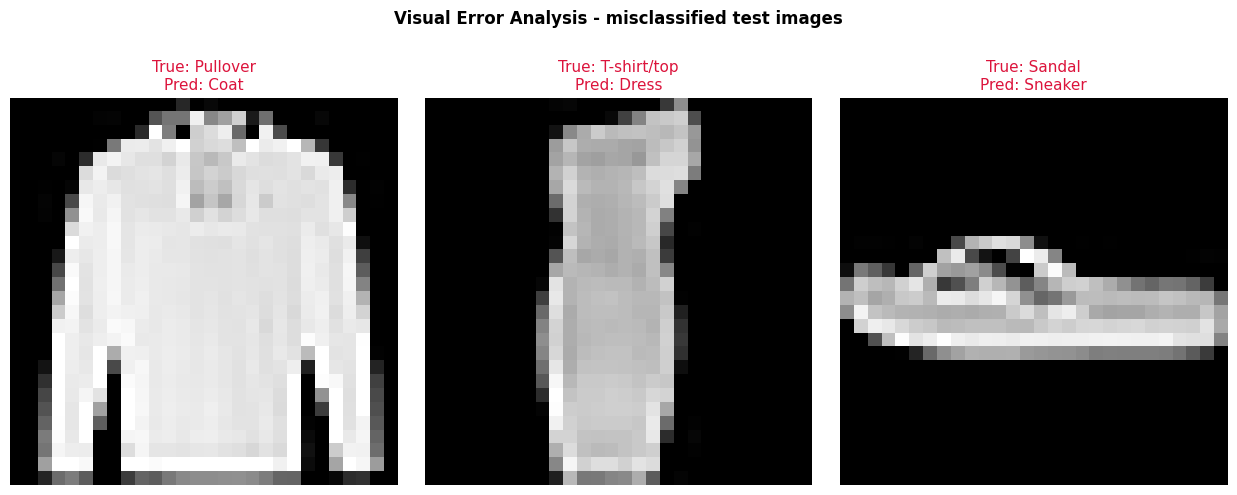

809 of 10,000 test images were misclassified.


In [16]:
wrong_idx = np.where(test_preds != test_targets)[0]

if len(wrong_idx) == 0:
    print("No misclassified test images were found.")
else:
    n_show = min(3, len(wrong_idx))

    picks = np.random.default_rng(SEED).choice(
        wrong_idx,
        size=n_show,
        replace=False,
    )

    fig, axes = plt.subplots(
        1,
        n_show,
        figsize=(4.2 * n_show, 5.0),
    )

    axes = np.atleast_1d(axes)

    for ax, idx in zip(axes, picks):
        image, _ = test_set[int(idx)]

        ax.imshow(
            denormalize(image).squeeze(0).numpy(),
            cmap="gray",
        )

        ax.set_title(
            f"True: {CLASS_NAMES[test_targets[idx]]}\n"
            f"Pred: {CLASS_NAMES[test_preds[idx]]}",
            color="crimson",
            fontsize=11,
        )

        ax.axis("off")

    fig.suptitle(
        "Visual Error Analysis - misclassified test images",
        fontweight="bold",
    )

    fig.tight_layout(
        rect=(0, 0, 1, 0.90)
    )

    plt.show()

    print(
        f"{len(wrong_idx):,} of "
        f"{len(test_targets):,} test images were misclassified."
    )


---
## 6. Real-world testing on my own custom photos

These ten files are real-world images and may have a large domain gap from FashionMNIST:
high resolution, RGB color, different framing, backgrounds, and object orientation.

The notebook therefore performs a preparation step before applying the exact evaluation
transform used by the standard test set.


In [17]:
def _should_invert(gray_img, border_frac=0.12):
    arr = np.asarray(gray_img, dtype=np.float32)
    h, w = arr.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    border = np.concatenate([arr[:bh, :].ravel(), arr[-bh:, :].ravel(), arr[:, :bw].ravel(), arr[:, -bw:].ravel()])
    centre = arr[int(h * 0.3):int(h * 0.7), int(w * 0.3):int(w * 0.7)]
    return float(np.median(border)) > float(np.median(centre))

def _crop_to_object(gray_img, pad_frac=0.06):
    arr = np.asarray(gray_img, dtype=np.float32)
    mask = arr > (arr.mean() + 0.35 * arr.std())
    if mask.sum() < 32: return gray_img
    rows, cols = np.where(mask.any(axis=1))[0], np.where(mask.any(axis=0))[0]
    top, bottom, left, right = rows[0], rows[-1], cols[0], cols[-1]
    side = max(bottom - top, right - left)
    pad = int(side * pad_frac)
    side += 2 * pad
    cy, cx = (top + bottom) // 2, (left + right) // 2
    return gray_img.crop((cx - side // 2, cy - side // 2, cx + side // 2, cy + side // 2))

def prepare_photo(path, invert="auto", autocrop=True):
    raw = ImageOps.exif_transpose(Image.open(path))
    gray = raw.convert("L")
    do_invert = _should_invert(gray) if invert == "auto" else bool(invert)
    if do_invert: gray = ImageOps.invert(gray)
    if autocrop: gray = _crop_to_object(gray)
    gray = ImageOps.autocontrast(gray, cutoff=1)
    return gray, {"inverted": do_invert, "autocropped": autocrop}

@torch.no_grad()
def predict_image(model, pil_img, device, transform=EVAL_TRANSFORM):
    model.eval()
    tensor = transform(pil_img).unsqueeze(0).to(device)
    probs = torch.softmax(model(tensor), dim=1).squeeze(0).cpu().numpy()
    return int(probs.argmax()), probs

photo_paths = [str(DATASET_DIR / filename) for filename in CUSTOM_FILENAMES]
print(f"Found {len(photo_paths)} custom images:")
for path in photo_paths: print(" ", os.path.basename(path))

Found 10 custom images:
  01_shirt.jpg
  02_hoodie.jpg
  03_cardigan.jpg
  04_jacket.jpg
  05_dress.jpg
  06_cap.jpg
  07_sandal.jpg
  08_boot.jpg
  09_backpack.jpg
  10_Handbag.jpg


### 6.1 The preprocessing pipeline, step by step


In [ ]:
# Walk the first custom photo through every stage so the transformation is auditable.
demo_path = photo_paths[0]

raw = ImageOps.exif_transpose(
    Image.open(demo_path)
)

prepared, info = prepare_photo(demo_path)

tensor = EVAL_TRANSFORM(prepared)

stages = [
    (
        raw,
        f"1. Raw photo\n{raw.size[0]}x{raw.size[1]} {raw.mode}",
    ),
    (
        raw.convert("L"),
        "2. Grayscale",
    ),
    (
        prepared,
        f"3. Inverted={info['inverted']} + cropped",
    ),
    (
        denormalize(tensor).squeeze(0).numpy(),
        "4. Resized 28x28 + normalised",
    ),
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(15, 4.3),
)

for ax, (img, title) in zip(axes, stages):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

fig.suptitle(
    f"Photo preprocessing pipeline - {os.path.basename(demo_path)}",
    fontweight="bold",
)

fig.tight_layout()
plt.show()

print(
    f"Final tensor shape: {tuple(tensor.shape)} "
    "- identical to a FashionMNIST sample."
)


### 6.2 Prediction gallery

Each of the 10 custom photos is shown with its **predicted class** and **softmax confidence**.

The original filename is displayed exactly as supplied.


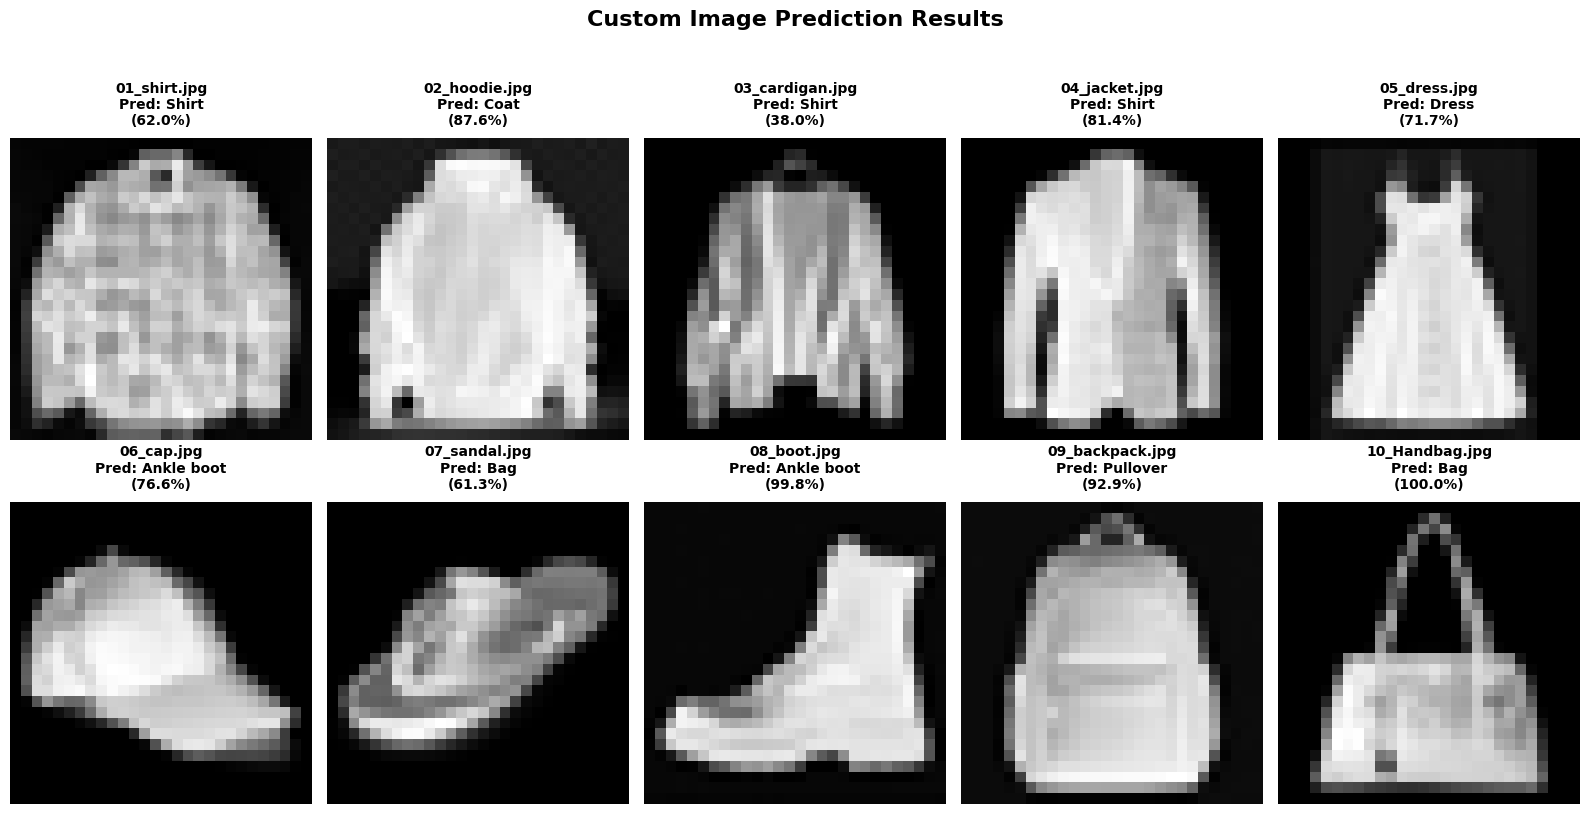

In [23]:
model.eval()
records = []

# Layout configuration based on the user's preferred style
cols = 5
n_rows = int(np.ceil(len(photo_paths) / cols))
fig, axes = plt.subplots(n_rows, cols, figsize=(16, 4.5 * n_rows))
axes = axes.ravel()

for i, path in enumerate(photo_paths):
    prepared, prep_info = prepare_photo(path)
    pred_idx, probs = predict_image(model, prepared, device)

    # Display the processed image
    axes[i].imshow(prepared.resize((28, 28)), cmap="gray")
    axes[i].axis("off")

    conf = probs[pred_idx] * 100
    pred_label = CLASS_NAMES[pred_idx]
    filename = os.path.basename(path)

    # Styling the title similar to the screenshot provided
    title_text = f"{filename}\nPred: {pred_label}\n({conf:.1f}%)"
    axes[i].set_title(title_text, fontsize=10, fontweight='bold', pad=10)

    records.append({
        "filename": filename,
        "predicted_class": pred_label,
        "confidence": float(conf),
        "probabilities": probs
    })

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Custom Image Prediction Results", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 6.3 Top-3 probabilities per photo


In [ ]:
print(
    f"{'File':<22}"
    f"{'Predicted':<18}"
    f"{'Conf':>8}   "
    f"Top-3 softmax probabilities"
)

print("-" * 110)

for record in records:
    probs = record["probabilities"]

    top3 = np.argsort(probs)[::-1][:3]

    detail = "  ".join(
        f"{CLASS_NAMES[i]} {probs[i]*100:.1f}%"
        for i in top3
    )

    print(
        f"{record['filename']:<22}"
        f"{record['predicted_class']:<18}"
        f"{record['confidence']:7.1f}%   "
        f"{detail}"
    )


---
## 7. Summary

| Item | Value |
|---|---|
| Student ID | `220144` |
| Dataset | FashionMNIST |
| Standard dataset | 60,000 training / 10,000 test |
| Image resolution | 28×28 grayscale |
| Classes | 10 |
| Architecture | 3 convolutional blocks (32→64→128) + 2 FC layers |
| Loss | `nn.CrossEntropyLoss` |
| Optimizer | `torch.optim.Adam` |
| Learning rate | `1e-3` |
| Saved weights | `model/220144.pth` |
| Custom images | 10 exact files in `dataset/` |

The final cells print the actual metrics produced by this run.


In [19]:
print(f"Trainable parameters        : {trainable:,}")
if history: print(f"Best validation accuracy    : {max(history['val_acc'])*100:.2f}%")
print(f"Standard test-set accuracy  : {test_acc*100:.2f}%")
print(f"\nWeights saved at            : {WEIGHTS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Custom images processed     : {len(records)}/{len(CUSTOM_FILENAMES)}")
print("\nCustom prediction outputs:")
for record in records: print(f"  {record['filename']:<20} -> {record['predicted_class']:<14} ({record['confidence']:.2f}%)")

Trainable parameters        : 437,226
Best validation accuracy    : 92.30%
Standard test-set accuracy  : 91.91%

Weights saved at            : model/220144.pth
Custom images processed     : 10/10

Custom prediction outputs:
  01_shirt.jpg         -> Shirt          (62.01%)
  02_hoodie.jpg        -> Coat           (87.63%)
  03_cardigan.jpg      -> Shirt          (38.05%)
  04_jacket.jpg        -> Shirt          (81.40%)
  05_dress.jpg         -> Dress          (71.68%)
  06_cap.jpg           -> Ankle boot     (76.59%)
  07_sandal.jpg        -> Bag            (61.32%)
  08_boot.jpg          -> Ankle boot     (99.84%)
  09_backpack.jpg      -> Pullover       (92.89%)
  10_Handbag.jpg       -> Bag            (100.00%)


In [22]:
from google.colab import files

# This will trigger a browser download for your model weights
if WEIGHTS_PATH.exists():
    files.download(str(WEIGHTS_PATH))
else:
    print(f"File not found at {WEIGHTS_PATH}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 8. Final compliance checks

The checks below verify the major implementation requirements before submission.


In [20]:
checks = {
    "Student ID is 220144": STUDENT_ID == "220144",
    "10 exact custom filenames configured": len(CUSTOM_FILENAMES) == 10,
    "10 custom images exist": all((DATASET_DIR / f).is_file() for f in CUSTOM_FILENAMES),
    "FashionMNIST train set loaded": len(train_set) == 54000,
    "FashionMNIST validation set loaded": len(val_set) == 6000,
    "FashionMNIST test set loaded": len(test_set) == 10000,
    "CNN is nn.Module": isinstance(model, nn.Module),
    "Model has Conv2d": any(isinstance(m, nn.Conv2d) for m in model.modules()),
    "Model has ReLU": any(isinstance(m, nn.ReLU) for m in model.modules()),
    "Model has MaxPool2d": any(isinstance(m, nn.MaxPool2d) for m in model.modules()),
    "Model has Linear": any(isinstance(m, nn.Linear) for m in model.modules()),
    "Saved model exists": WEIGHTS_PATH.exists(),
    "10 custom predictions generated": len(records) == 10,
    "Confidence values are valid": all(0.0 <= r["confidence"] <= 100.0 for r in records),
}

all_pass = True
for requirement, status in checks.items():
    print(f"{'PASS' if status else 'FAIL':<5} | {requirement}")
    all_pass = all_pass and status

print("\nOverall core notebook check:", "PASS" if all_pass else "FAIL")
if all_pass:
    print("Core notebook requirements passed.")
else:
    print("Review the failed checks before submission.")

PASS  | Student ID is 220144
PASS  | 10 exact custom filenames configured
PASS  | 10 custom images exist
PASS  | FashionMNIST train set loaded
PASS  | FashionMNIST validation set loaded
PASS  | FashionMNIST test set loaded
PASS  | CNN is nn.Module
PASS  | Model has Conv2d
PASS  | Model has ReLU
PASS  | Model has MaxPool2d
PASS  | Model has Linear
PASS  | Saved model exists
PASS  | 10 custom predictions generated
PASS  | Confidence values are valid

Overall core notebook check: PASS
Core notebook requirements passed.
